# Example-10: Twiss from invariant fit (uncoupled)

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# In this example CS twiss parameters are estimated from (linear) invariants fit

# Given (filtered) TbT data at each monitor location, twiss parameters at each probed monitor are estimated using x & y signals
# Other monitors are used to compute momentum at the probed monitor using model (or measured) transport matrix
# Using coordinates and momenta linear invariants are fitted
# Known invariant values can be passed, else both invariant values and twiss parameters are fitted
# Fit objective is ((jx(qx, px, qy, py; beta) - ix)**2 + (jy(qx, px, qy, py; beta) - iy)**2).sqrt()
# Or ((jx(qx, px, qy, py; beta) - ix)**2 * (jy(qx, px, qy, py; beta) - iy)**2).sqrt() (default)
# Where, for uncoupled case, beta = (ax, bx, ay, by) and ix & iy are invariant values (can be fixed on input or estimated)
# Fitting is be performed using nonlinear least squares
# Note, fitting is bootstrapped (signals are randomly sampled with replacement)
# The result is returned for each sample (values and errors) at each monitor location (beta or beta and invariants)
# Processing (filtering and weighting) is then performed over samples for each monitor location
# Ones invariants are estimated, fit can be performed with fixed invariants (this can improve result quality in some cases)

# Here, random normal thin quadrupole errors are introduced and twiss parameters estimation is performed using amplitude & phase data
# These results are compared with fitted values

# Note, in this example unfiltered TbT data is used
# Note, for computation of momenta at the probed monitor, only the next monitor is used
# Methods using several monitors are also avaliable

In [4]:
# Set model with normal errors

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-3, 0.0E-3, length=0.01)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

mqx, mqy = model.out_tune_fractional

True


torch.Size([54, 1024, 4])

4.043346142e-07, 1.677701523e-19
1.263757028e-07, 5.855679079e-20



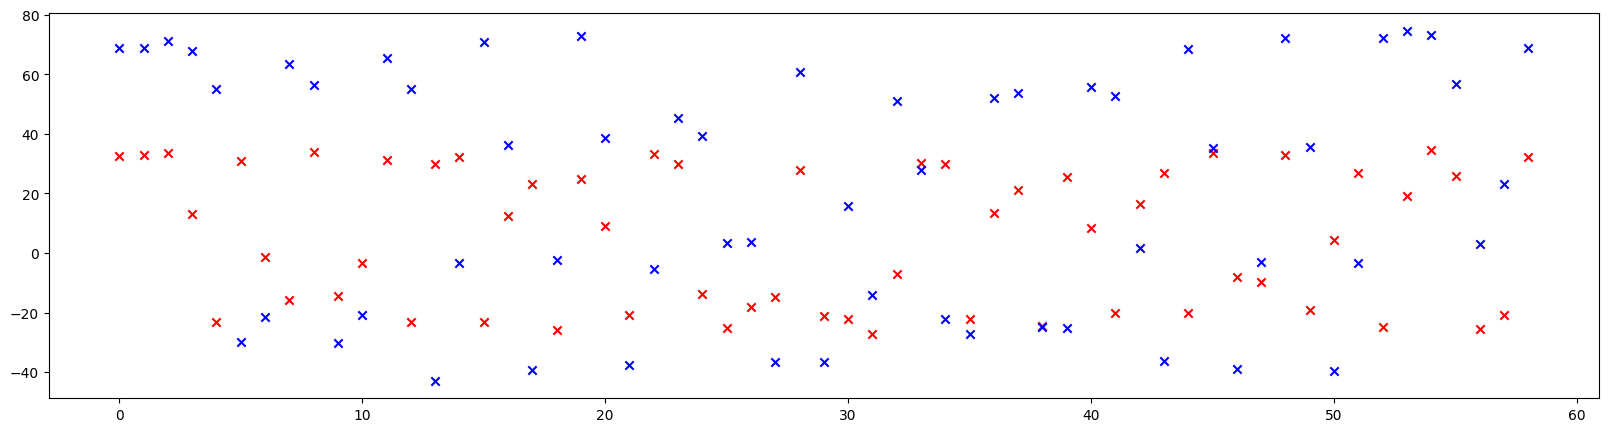

tensor(1.083190998033e+02, dtype=torch.float64)
tensor(3.192442237902e+02, dtype=torch.float64)



In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)[model.monitor_index]
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[..., 0]
y = trajectory[..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[model.monitor_index[index]], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

# Compare model and real beta function values

from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

cs_ax, cs_bx, cs_ay, cs_by = torch.stack([wolski_to_cs(w) for w in normal_to_wolski(model.out_normal)]).T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.size), 100*(cs_bx - model.bx)/model.bx, color='red', marker='x')
plt.scatter(range(model.size), 100*(cs_by - model.by)/model.by, color='blue', marker='x')
plt.show()

error_x = (cs_bx[model.monitor_index] - model.bx[model.monitor_index]).abs().sum()
error_y = (cs_by[model.monitor_index] - model.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_y)
print()

In [6]:
# Generate TbT data

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x)
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y)
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [7]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx= 0.573854121
nux= 0.573854108, sigma_nux=1.41568047e-07, error_nux=1.31460015e-08


In [8]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(mqy - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.619464715
nuy= 0.619464735, sigma_nuy=1.69601363e-07, error_nuy=1.99984168e-08


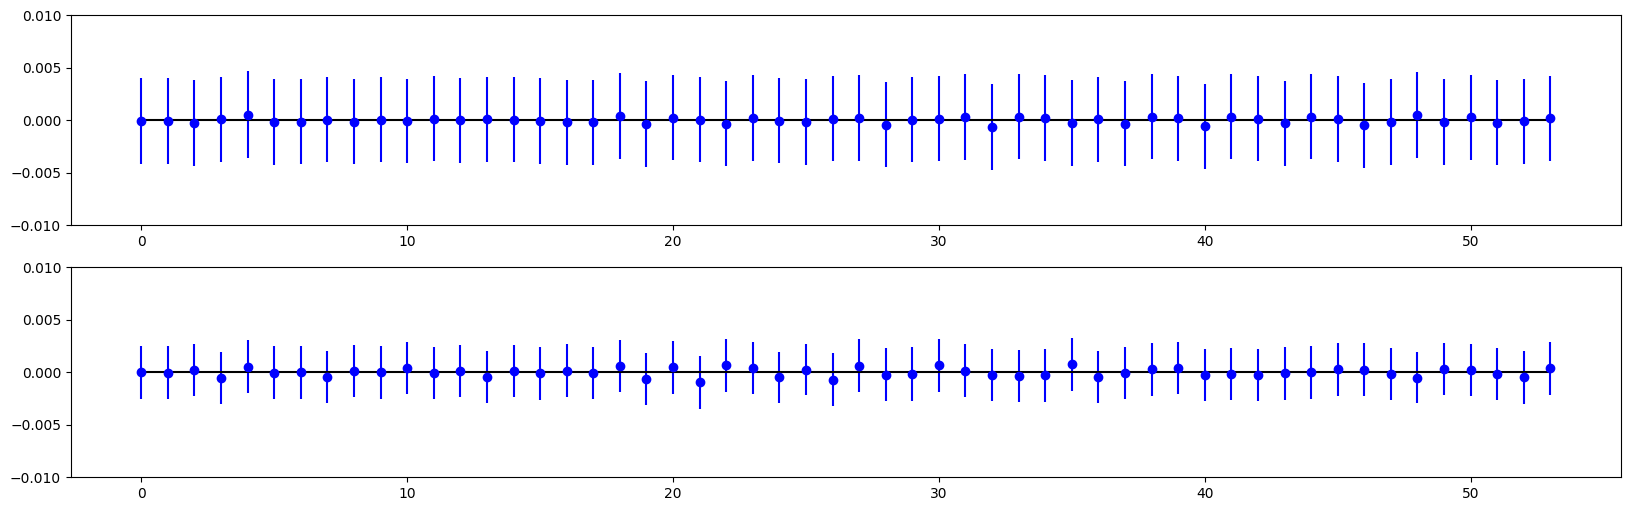

In [9]:
# Set table

table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'],
    nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    dtype=dtype, device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(mqx, mux)
muy, _ = Decomposition.phase_adjacent(mqy, muy)

plt.figure(figsize=(20, 3*2))

ax1 = plt.subplot(211)
ax1.errorbar(range(model.monitor_count), (mux - table.phase_x).cpu().numpy(), yerr=table.sigma_x.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.hlines(0, 0, model.monitor_count - 1, colors='black')
ax1.set_ylim(-1.0E-2, +1.0E-2)

ax2 = plt.subplot(212)
ax2.errorbar(range(model.monitor_count), (muy - table.phase_y).cpu().numpy(), yerr=table.sigma_y.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.hlines(0, 0, model.monitor_count - 1, colors='black')
ax2.set_ylim(-1.0E-2, +1.0E-2)

plt.show()

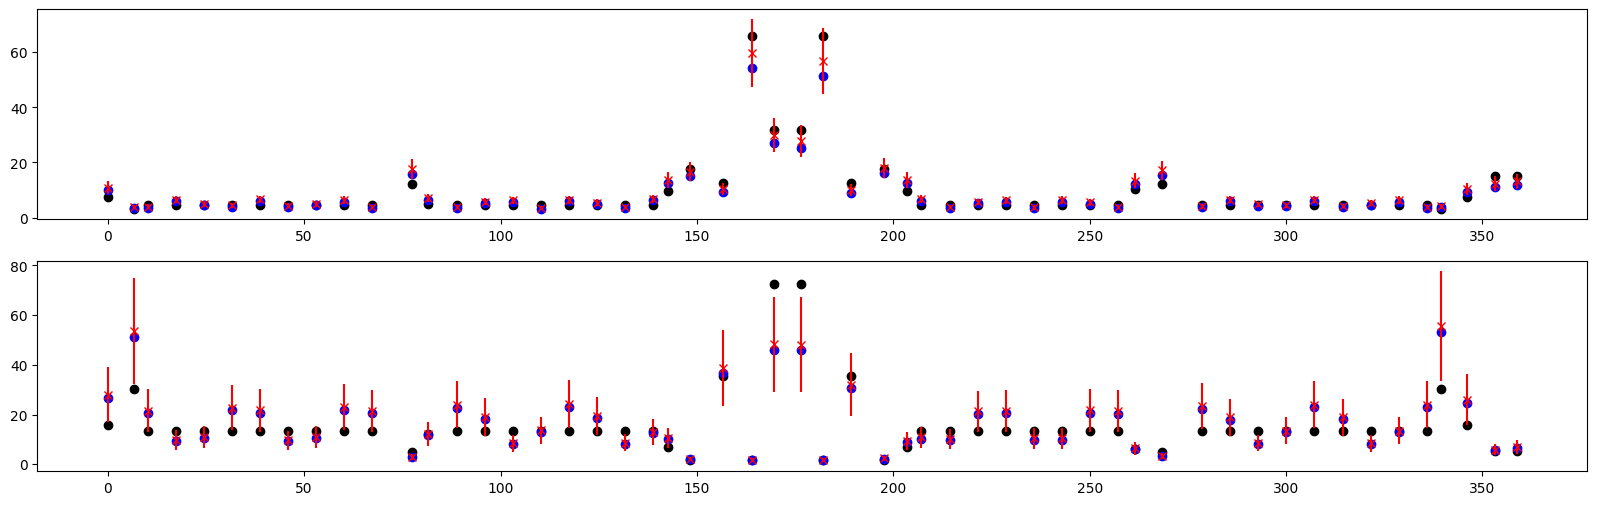

tensor(1.083190998033e+02, dtype=torch.float64)
tensor(5.063812054154e+01, dtype=torch.float64)

tensor(3.192442237902e+02, dtype=torch.float64)
tensor(4.494664728979e+01, dtype=torch.float64)



In [10]:
# Estimate twiss from amplitude

twiss = Twiss(model, table, limit=1)
twiss.get_action()
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_1 = (cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum()
error_y_1 = (cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum()

print(error_x)
print(error_x_1)
print()

print(error_y)
print(error_y_1)
print()

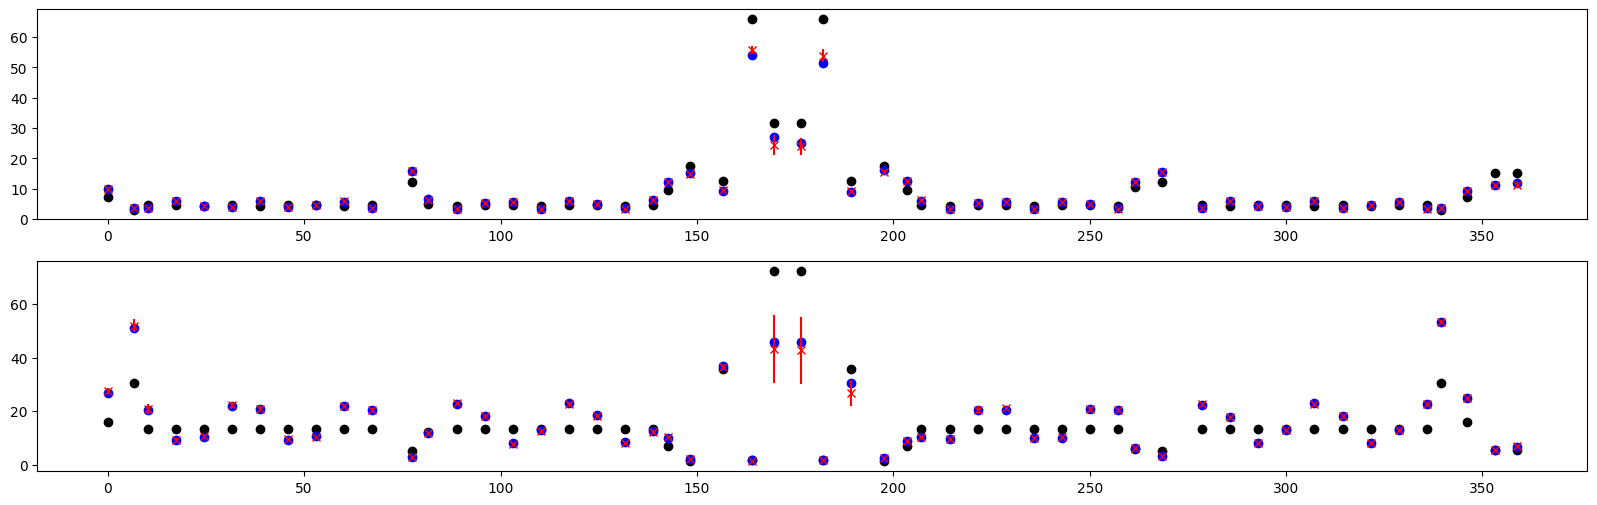

tensor(1.083190998033e+02, dtype=torch.float64)
tensor(5.063812054154e+01, dtype=torch.float64)
tensor(1.129223017475e+01, dtype=torch.float64)

tensor(3.192442237902e+02, dtype=torch.float64)
tensor(4.494664728979e+01, dtype=torch.float64)
tensor(1.842936010981e+01, dtype=torch.float64)



In [11]:
# Estimate twiss from phase

twiss = Twiss(model, table, limit=4)
twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
twiss.process_twiss(plane='x', mask=mask_x, weight=True)
twiss.process_twiss(plane='y', mask=mask_y, weight=True)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.bx[model.monitor_index].cpu().numpy(), yerr=twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.by[model.monitor_index].cpu().numpy(), yerr=twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_2 = (cs_bx[model.monitor_index] - twiss.bx[model.monitor_index]).abs().sum()
error_y_2 = (cs_by[model.monitor_index] - twiss.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print()

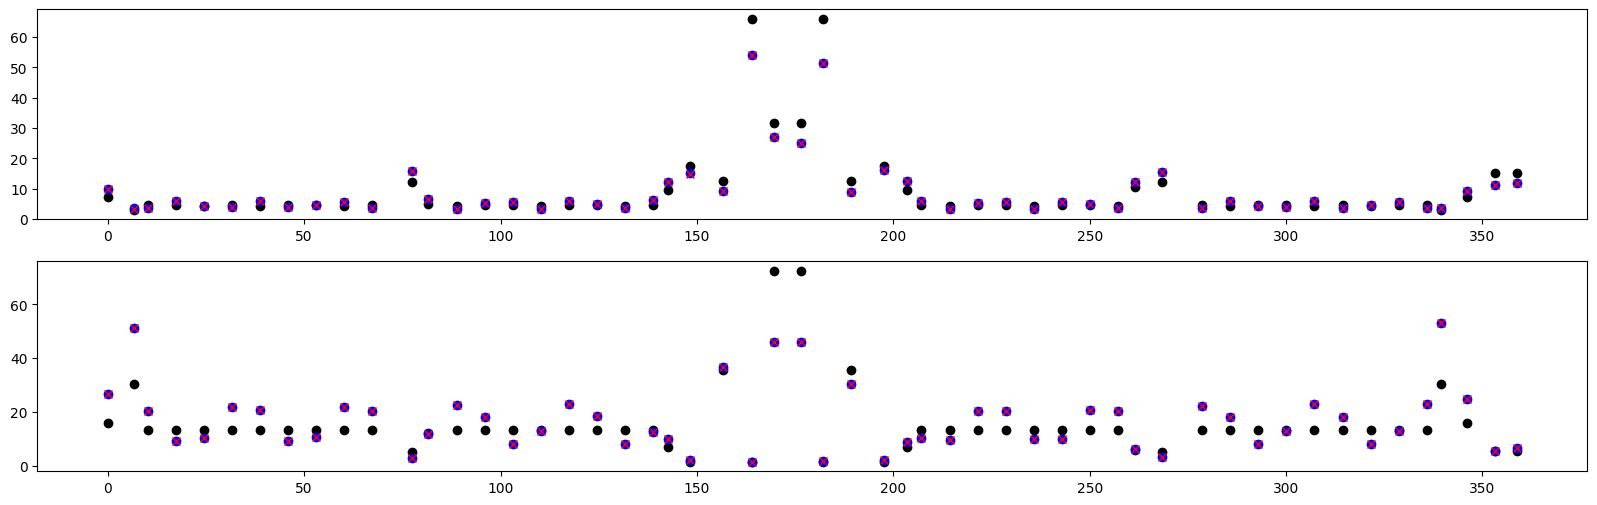

tensor(1.083190998033e+02, dtype=torch.float64)
tensor(5.063812054154e+01, dtype=torch.float64)
tensor(1.129223017475e+01, dtype=torch.float64)
tensor(8.876696435645e-01, dtype=torch.float64)

tensor(3.192442237902e+02, dtype=torch.float64)
tensor(4.494664728979e+01, dtype=torch.float64)
tensor(1.842936010981e+01, dtype=torch.float64)
tensor(3.801092932684e-01, dtype=torch.float64)



In [12]:
# Estimate twiss from amplitude (corrected action)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_3 = (cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum()
error_y_3 = (cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print()

In [13]:
%%time

# Estimate twiss from invariant fit
# Note, **kwargs are passed to leastsq

from harmonica.parameterization import cs_normal
data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 cs_normal,        # -- normalization
                                 model.matrix,     # -- matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='pair',    # -- momenta computation method
                                 limit=1,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=512,        # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=12,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag
print(data.shape)

torch.Size([54, 2, 6, 512])
CPU times: user 1min 9s, sys: 3.62 s, total: 1min 13s
Wall time: 1min 19s


In [14]:
# Process fitted invariants

ix = data[:, 0, 0]
iy = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix, iy, sigma_ix, sigma_iy)

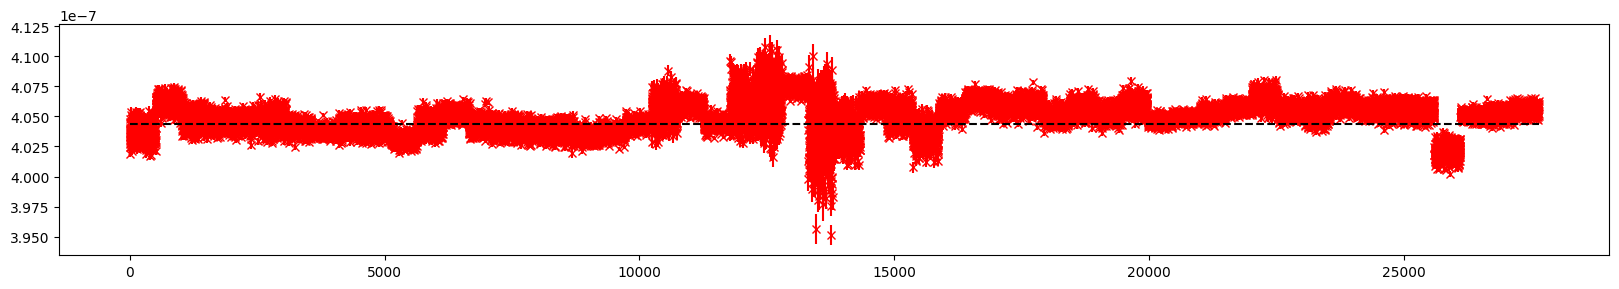

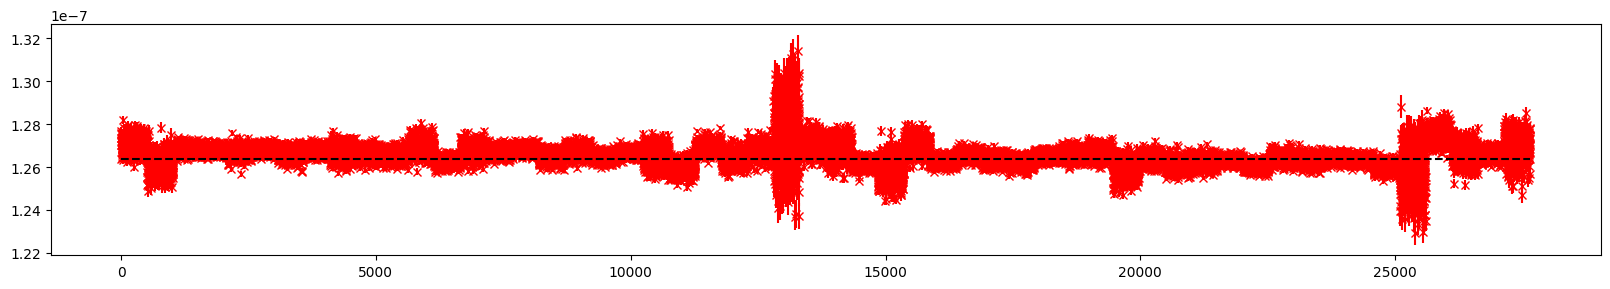

In [15]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(54*512), ix.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(action_x, 0, 54*512, linestyles='dashed', color='black',  zorder=1)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54*512), iy.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(action_y, 0, 54*512, linestyles='dashed', color='black',  zorder=1)
plt.show()

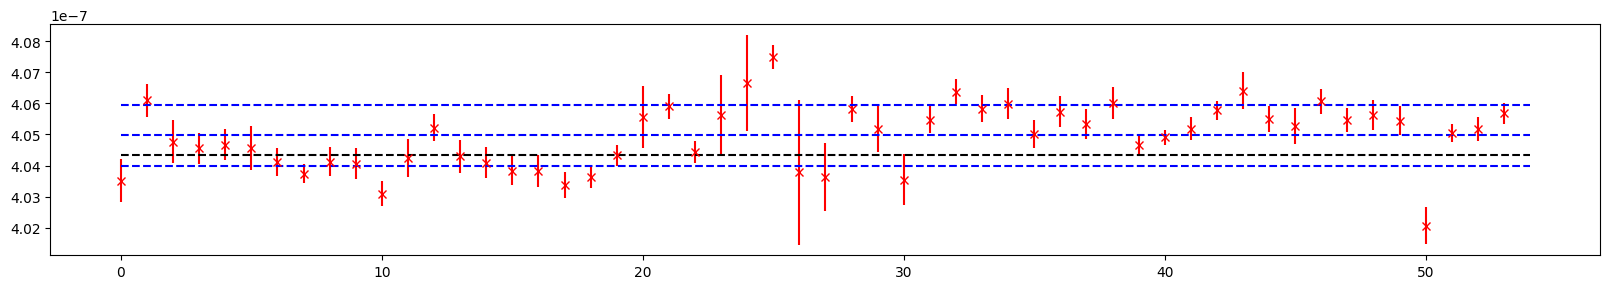

tensor(4.043346142366e-07, dtype=torch.float64)
tensor(4.049732146754e-07, dtype=torch.float64)
tensor(9.740720184308e-10, dtype=torch.float64)



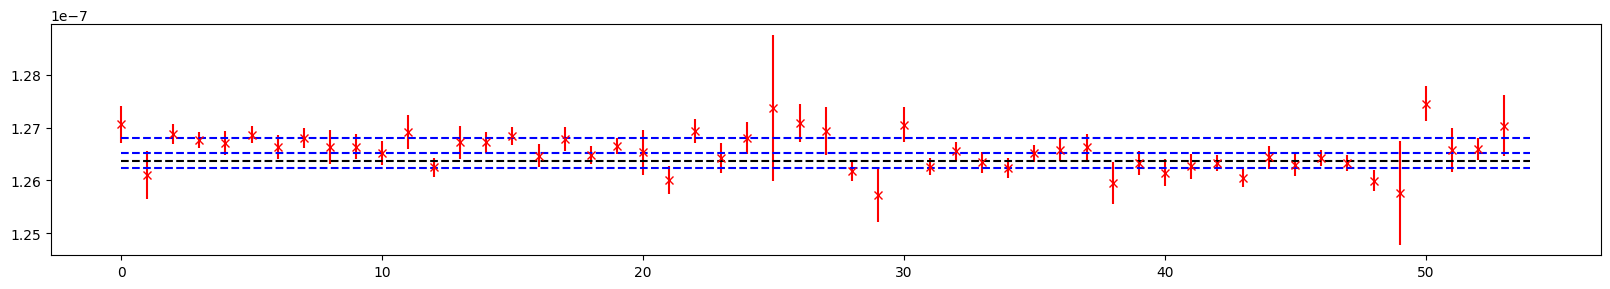

tensor(1.263757027843e-07, dtype=torch.float64)
tensor(1.265187521986e-07, dtype=torch.float64)
tensor(2.853639685812e-10, dtype=torch.float64)



In [16]:
# Plot invariants for each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_x, 0, 54, linestyles='dashed', color='black')
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, 54, linestyles='dashed', color='blue')
plt.show()

print(action_x)
print(invariant['ix_value'])
print(invariant['ix_error'])
print()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_y, 0, 54, linestyles='dashed', color='black')
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, 54, linestyles='dashed', color='blue')
plt.show()

print(action_y)
print(invariant['iy_value'])
print(invariant['iy_error'])
print()

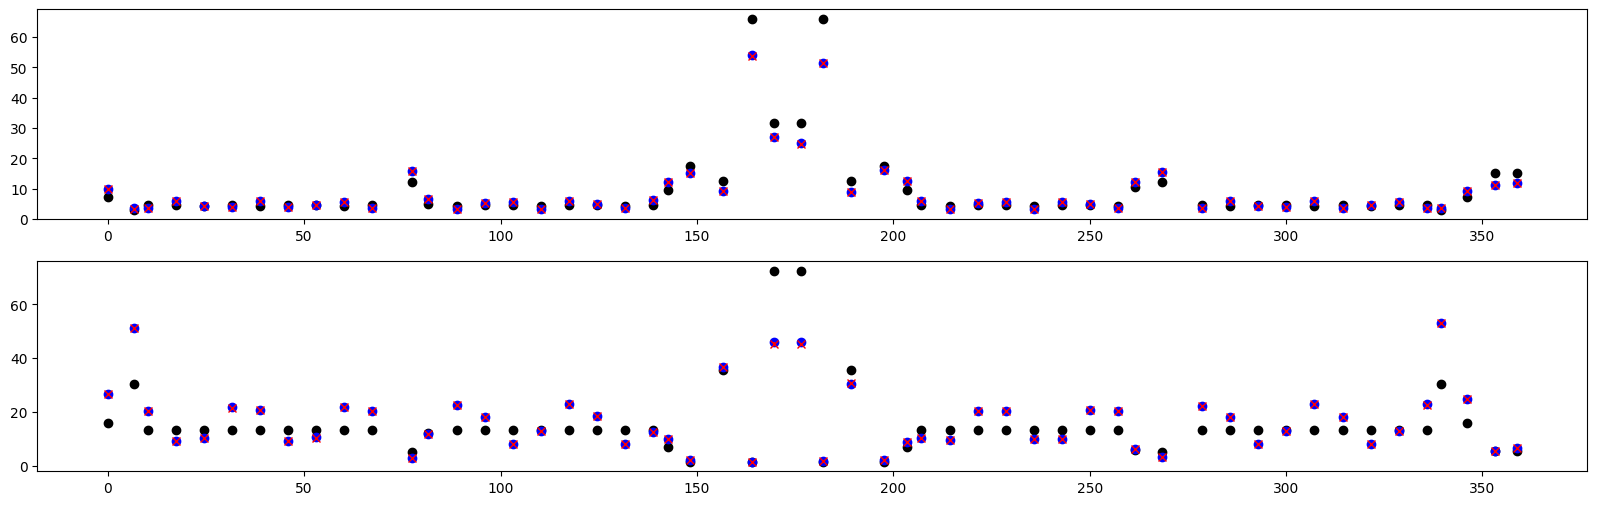

tensor(1.083190998033e+02, dtype=torch.float64)
tensor(5.063812054154e+01, dtype=torch.float64)
tensor(1.129223017475e+01, dtype=torch.float64)
tensor(8.876696435645e-01, dtype=torch.float64)
tensor(1.684659061870e+00, dtype=torch.float64)

tensor(3.192442237902e+02, dtype=torch.float64)
tensor(4.494664728979e+01, dtype=torch.float64)
tensor(1.842936010981e+01, dtype=torch.float64)
tensor(3.801092932684e-01, dtype=torch.float64)
tensor(3.023644533717e+00, dtype=torch.float64)



In [17]:
# Process twiss & compare

mask = invariant['ix_mask']*invariant['sx_mask']*invariant['iy_mask']*invariant['sy_mask']

value_ax = data[:, 0, 2]
error_ax = data[:, 1, 2]

value_bx = data[:, 0, 3]
error_bx = data[:, 1, 3]

value_ay = data[:, 0, 4]
error_ay = data[:, 1, 4]

value_by = data[:, 0, 5]
error_by = data[:, 1, 5]

value_ax, error_ax = twiss.process(value_ax, error_ax, mask=mask)
value_bx, error_bx = twiss.process(value_bx, error_bx, mask=mask)
value_ay, error_ay = twiss.process(value_ay, error_ay, mask=mask)
value_by, error_by = twiss.process(value_by, error_by, mask=mask)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_bx.cpu().numpy(), yerr=error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_by.cpu().numpy(), yerr=error_by.cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_4 = (cs_bx[model.monitor_index] - value_bx).abs().sum()
error_y_4 = (cs_by[model.monitor_index] - value_by).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print(error_x_4)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print(error_y_4)
print()

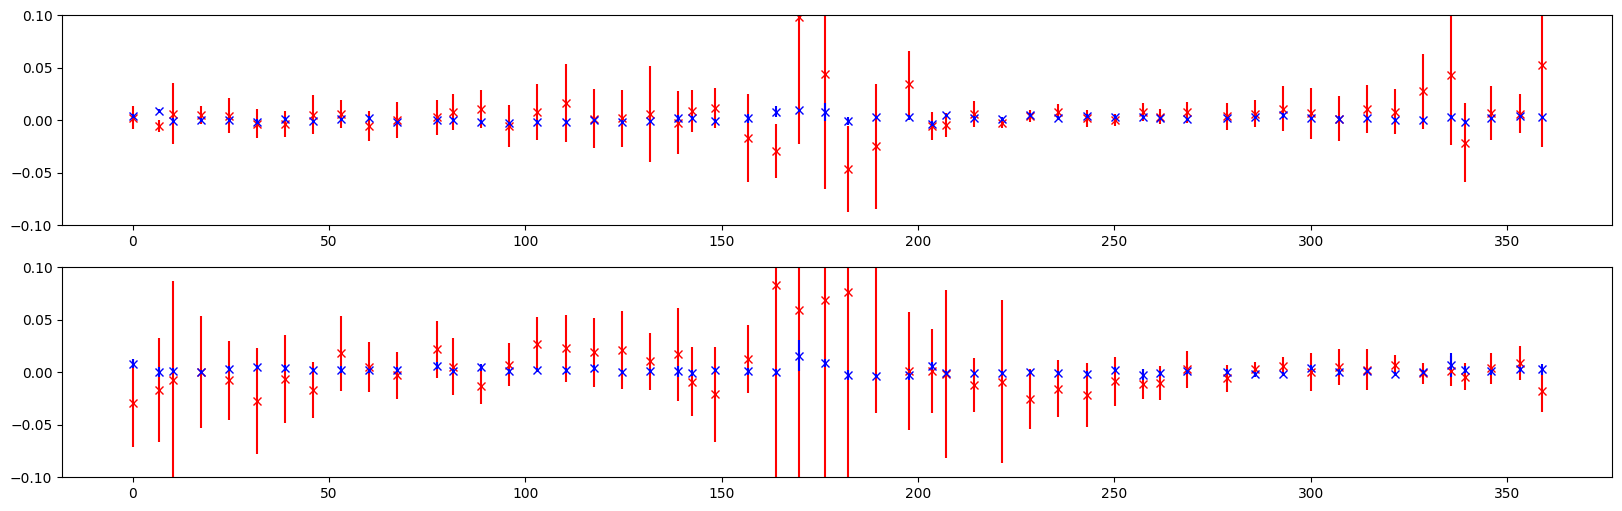

In [18]:
# Plot errors from phase (red) vs fit (blue)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_bx[model.monitor_index] - twiss.bx[model.monitor_index])/cs_bx[model.monitor_index]).cpu().numpy(), yerr=(twiss.sigma_bx[model.monitor_index]/cs_bx[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_bx[model.monitor_index] - value_bx)/cs_bx[model.monitor_index]).cpu().numpy(), yerr=(error_bx/cs_bx[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.set_ylim(-1.0E-1, +1.0E-1)

ax = plt.subplot(212)
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_by[model.monitor_index] - twiss.by[model.monitor_index])/cs_by[model.monitor_index]).cpu().numpy(), yerr=(twiss.sigma_by[model.monitor_index]/cs_by[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_by[model.monitor_index] - value_by)/cs_by[model.monitor_index]).cpu().numpy(), yerr=(error_by/cs_by[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.set_ylim(-1.0E-1, +1.0E-1)

plt.show()

In [19]:
%%time

# Estimate twiss from invariant fit (use first 256 turns and 512 random samples and fixed invariants)

from harmonica.parameterization import cs_normal
data = twiss.get_twiss_from_data(1, 256, cs_normal, model.matrix, twiss=None, method='pair', limit=1, product=True, jacobian=False, count=512, fraction=0.75, ix=invariant['ix_value'], iy=invariant['iy_value'], n_jobs=12, verbose=False)
print(data.shape)

torch.Size([54, 2, 4, 512])
CPU times: user 1min 19s, sys: 4.22 s, total: 1min 23s
Wall time: 1min 28s


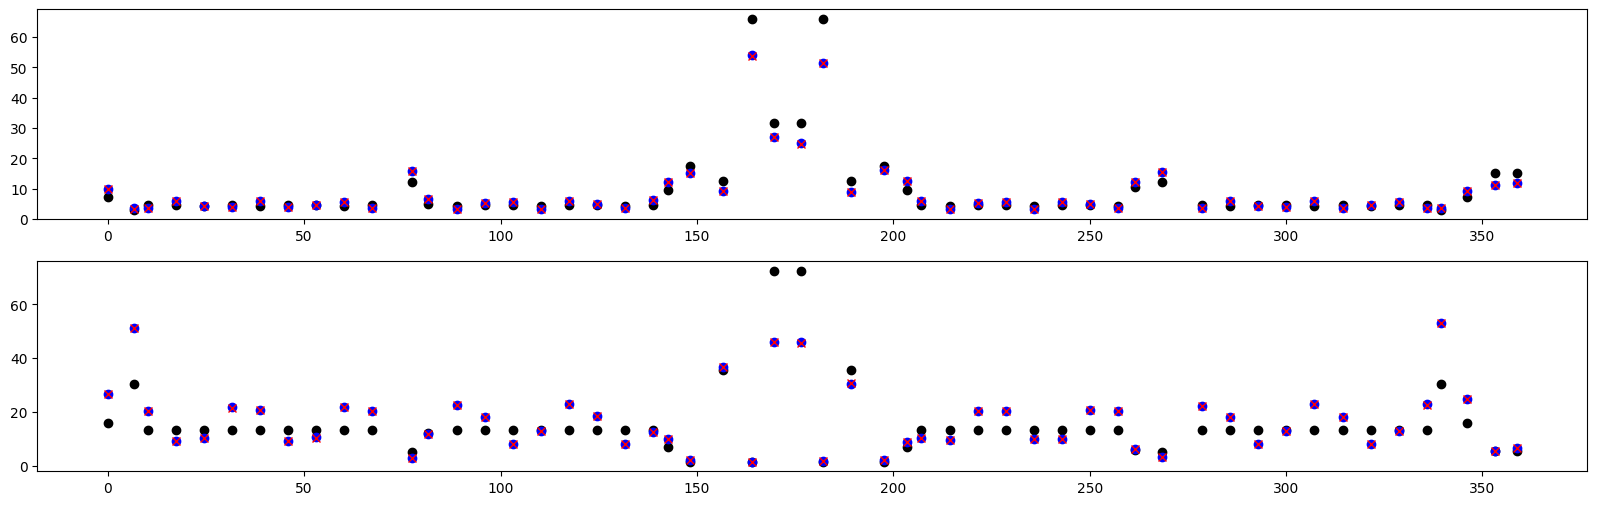

tensor(1.083190998033e+02, dtype=torch.float64)
tensor(5.063812054154e+01, dtype=torch.float64)
tensor(1.129223017475e+01, dtype=torch.float64)
tensor(8.876696435645e-01, dtype=torch.float64)
tensor(1.684659061870e+00, dtype=torch.float64)
tensor(1.595873827524e+00, dtype=torch.float64)

tensor(3.192442237902e+02, dtype=torch.float64)
tensor(4.494664728979e+01, dtype=torch.float64)
tensor(1.842936010981e+01, dtype=torch.float64)
tensor(3.801092932684e-01, dtype=torch.float64)
tensor(3.023644533717e+00, dtype=torch.float64)
tensor(2.196034232474e+00, dtype=torch.float64)



In [20]:
# Process twiss & compare

value_ax = data[:, 0, 0]
error_ax = data[:, 1, 0]

value_bx = data[:, 0, 1]
error_bx = data[:, 1, 1]

value_ay = data[:, 0, 2]
error_ay = data[:, 1, 2]

value_by = data[:, 0, 3]
error_by = data[:, 1, 3]

value_ax, error_ax = twiss.process(value_ax, error_ax)
value_bx, error_bx = twiss.process(value_bx, error_bx)
value_ay, error_ay = twiss.process(value_ay, error_ay)
value_by, error_by = twiss.process(value_by, error_by)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_bx.cpu().numpy(), yerr=error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_by.cpu().numpy(), yerr=error_by.cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_5 = (cs_bx[model.monitor_index] - value_bx).abs().sum()
error_y_5 = (cs_by[model.monitor_index] - value_by).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print(error_x_4)
print(error_x_5)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print(error_y_4)
print(error_y_5)
print()

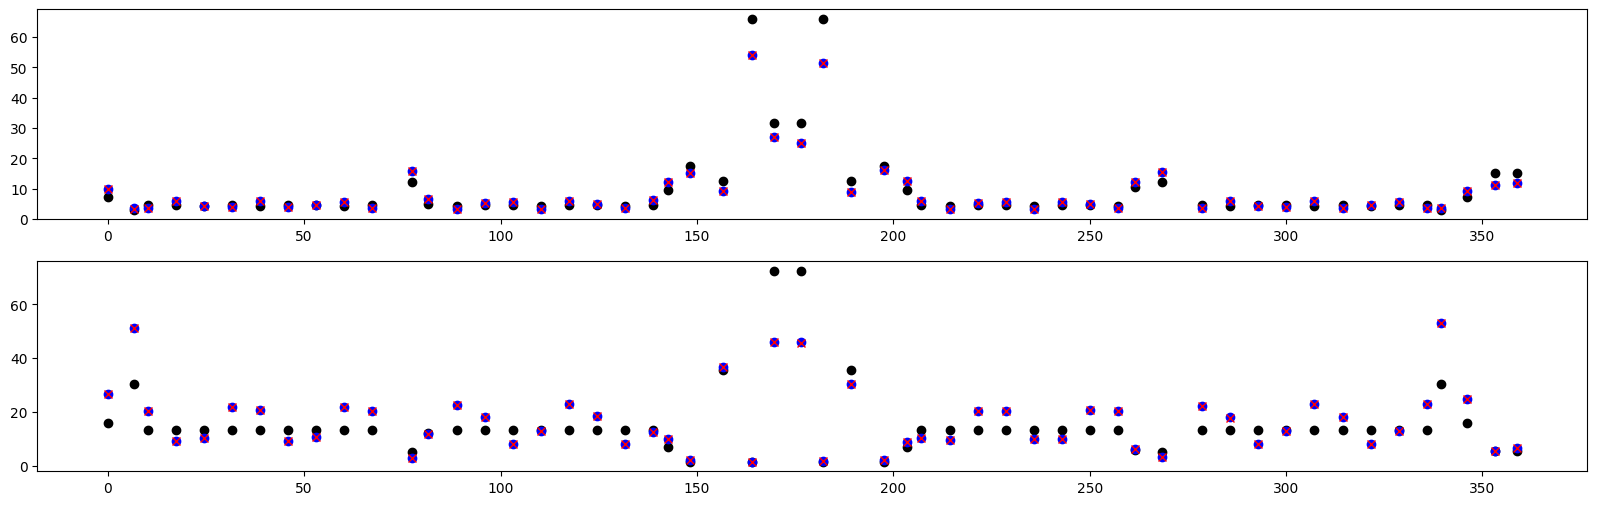

tensor(1.083190998033e+02, dtype=torch.float64)
tensor(5.063812054154e+01, dtype=torch.float64)
tensor(1.129223017475e+01, dtype=torch.float64)
tensor(8.876696435645e-01, dtype=torch.float64)
tensor(1.684659061870e+00, dtype=torch.float64)
tensor(1.595873827524e+00, dtype=torch.float64)
tensor(7.753379387742e-01, dtype=torch.float64)

tensor(3.192442237902e+02, dtype=torch.float64)
tensor(4.494664728979e+01, dtype=torch.float64)
tensor(1.842936010981e+01, dtype=torch.float64)
tensor(3.801092932684e-01, dtype=torch.float64)
tensor(3.023644533717e+00, dtype=torch.float64)
tensor(2.196034232474e+00, dtype=torch.float64)
tensor(9.544423081115e-01, dtype=torch.float64)



In [21]:
# Estimate twiss from amplitude (fixed action)

twiss.get_action(jx=invariant['ix_center'], jy=invariant['iy_center'], sigma_jx=invariant['ix_spread'], sigma_jy=invariant['iy_spread'])
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_6 = (cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum()
error_y_6 = (cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print(error_x_4)
print(error_x_5)
print(error_x_6)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print(error_y_4)
print(error_y_5)
print(error_y_6)
print()

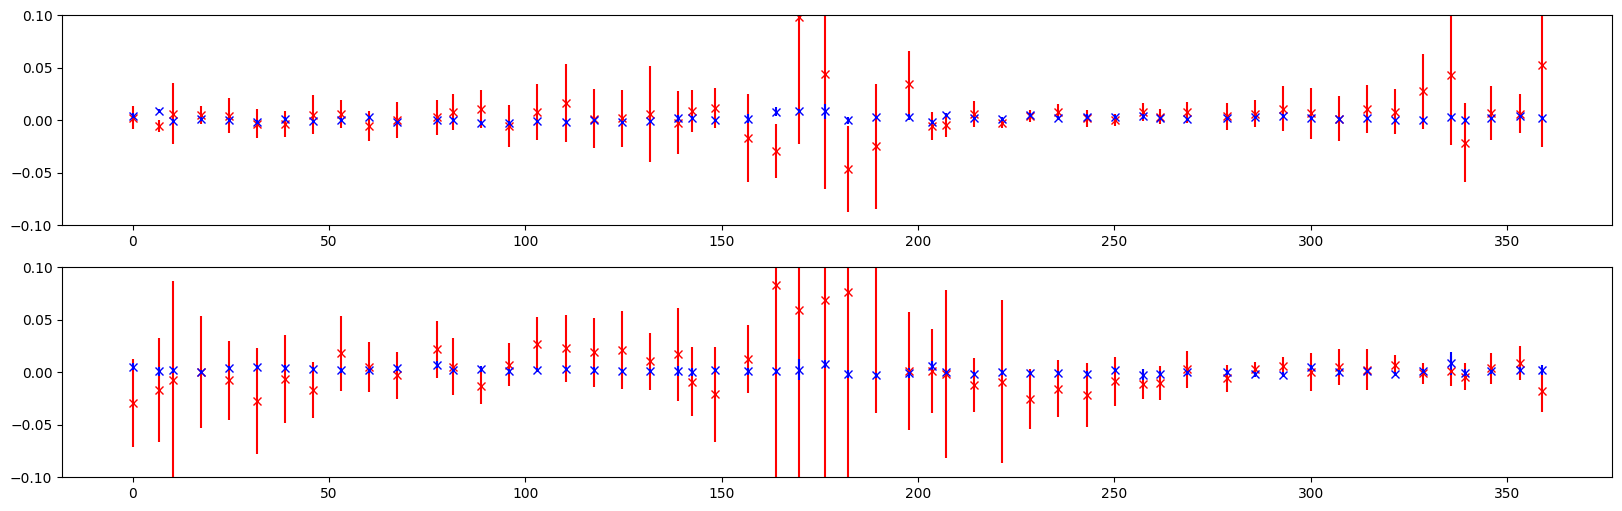

In [22]:
# Plot errors from phase (red) vs fit (blue)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_bx[model.monitor_index] - twiss.bx[model.monitor_index])/cs_bx[model.monitor_index]).cpu().numpy(), yerr=(twiss.sigma_bx[model.monitor_index]/cs_bx[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_bx[model.monitor_index] - value_bx)/cs_bx[model.monitor_index]).cpu().numpy(), yerr=(error_bx/cs_bx[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.set_ylim(-1.0E-1, +1.0E-1)

ax = plt.subplot(212)
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_by[model.monitor_index] - twiss.by[model.monitor_index])/cs_by[model.monitor_index]).cpu().numpy(), yerr=(twiss.sigma_by[model.monitor_index]/cs_by[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_by[model.monitor_index] - value_by)/cs_by[model.monitor_index]).cpu().numpy(), yerr=(error_by/cs_by[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.set_ylim(-1.0E-1, +1.0E-1)

plt.show()

In [23]:
# Compare alpha from phase vs fitted

print((cs_ax[model.monitor_index] - twiss.ax[model.monitor_index]).abs().sum())
print((cs_ax[model.monitor_index] - value_ax).abs().sum())
print()

print((cs_ay[model.monitor_index] - twiss.ay[model.monitor_index]).abs().sum())
print((cs_ay[model.monitor_index] - value_ay).abs().sum())
print()

tensor(3.272217473495e+00, dtype=torch.float64)
tensor(6.638029452805e-01, dtype=torch.float64)

tensor(3.939389385656e+00, dtype=torch.float64)
tensor(1.089162953263e+00, dtype=torch.float64)



In [24]:
%%time

# Twiss at virtual locations (from virtual orbits)
# Note, method='lstsq'

from harmonica.parameterization import cs_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 cs_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 phony=True,
                                 product=True,
                                 jacobian=False,
                                 count=512,
                                 fraction=0.75,
                                 ix=invariant['ix_value'],
                                 iy=invariant['iy_value'],
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)
print(model.virtual_count)

torch.Size([5, 2, 4, 512])
5
CPU times: user 7.16 s, sys: 368 ms, total: 7.53 s
Wall time: 7.9 s


In [25]:
# Process twiss

value_ax = data[:, 0, 0]
error_ax = data[:, 1, 0]

value_bx = data[:, 0, 1]
error_bx = data[:, 1, 1]

value_ay = data[:, 0, 2]
error_ay = data[:, 1, 2]

value_by = data[:, 0, 3]
error_by = data[:, 1, 3]

value_ax, error_ax = twiss.process(value_ax, error_ax)
value_bx, error_bx = twiss.process(value_bx, error_bx)
value_ay, error_ay = twiss.process(value_ay, error_ay)
value_by, error_by = twiss.process(value_by, error_by)

In [26]:
# Compare with exact values

for index, location in enumerate(model.virtual_index):
    print(torch.stack([model.ax[location], model.bx[location], model.ay[location], model.by[location]]).cpu().numpy())
    print(torch.stack([value_ax[index], value_bx[index], value_ay[index], value_by[index]]).cpu().numpy())
    print(model.out_cs[location].cpu().numpy())
    print()

[-0.67832172  7.46746094  0.65444028 15.85438815]
[-1.01959683  9.88823144  0.8680846  26.61593352]
[-1.00001929  9.89298716  0.8313487  26.76369946]

[ 1.95506501 14.23834264 -2.75987199 13.85574699]
[ 2.69756098 18.85216076 -4.60448329 23.73383524]
[ 2.72193885 19.03393381 -4.59310377 23.7136412 ]

[1.70086167e-13 7.50348193e-01 1.42108547e-14 6.77073993e-02]
[0.06519234 0.96073375 0.10731942 0.10939233]
[0.0653156  0.96002074 0.13678657 0.10875794]

[-1.95506501 14.23834264  2.75987199 13.85574699]
[-2.61773214 19.00598235  4.88376175 23.96364756]
[-2.67932151 19.17903521  4.92718781 23.9822274 ]

[-0.67832172  7.46746094  0.65444028 15.85438815]
[-1.01939814  9.88773036  0.86869114 26.62913437]
[-1.01432842  9.8728436   0.87627832 26.78077566]

